# Dependencies

In [1]:
import numpy as np
import pickle
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, silhouette_score

In [2]:
mocap_idx = {"left_shoulder": 1, "right_shoulder": 6,  "left_hip": 3,  "right_hip": 8,  "left_coord":2, "right_coord": 7, 
             "left_knee": 4,     "right_knee":     9,  "left_ankle":0, "right_ankle": 5}

sdannce_idx = {"left_shoulder": 7, "right_shoulder": 11, "left_hip": 15 ,    "right_hip": 19,
               "middle_spine":4, 
               "left_knee": 16,    "right_knee": 20,     "left_ankle":17,    "right_ankle":21}

In [3]:
def _unit(v, eps=1e-8):
    return v / (np.linalg.norm(v, axis=-1, keepdims=True) + eps)

def distance(a, b):
    return np.linalg.norm(a - b, axis=-1)

def _angle_between(v1, v2, eps=1e-8):
    """Angle in radians between two vectors"""
    v1n, v2n = _unit(v1, eps), _unit(v2, eps)
    cos_theta = np.sum(v1n * v2n, axis=-1).clip(-1.0, 1.0)
    return np.degrees(np.arccos(cos_theta)) # inverse of cos

def _central_diff(x):
    """Central difference along time axis. x: (T, ...) -> same shape."""
    d = np.zeros_like(x, dtype=float)
    d[1:-1] = (x[2:] - x[:-2]) / 2.0
    d[0] = x[1] - x[0]
    d[-1] = x[-1] - x[-2]
    return d


def smooth_sequence(seq, window=5):
    pad = window // 2
    kernel = np.ones(window) / window
    seq_smooth = np.empty_like(seq)
     # Smooth each joint and each coordinate independently
    for j in range(seq.shape[1]):   
        for c in range(seq.shape[2]):
            x = seq[:, j, c]
            x_pad = np.pad(x, (pad, pad), mode="edge")
            seq_smooth[:, j, c] = np.convolve(x_pad, kernel, mode="valid")
    return seq_smooth

## Note
- Smooth data when calculate
- Normaize bv body scale

# Main function

In [4]:
def compute_kinematic_features(seq , joints_idx, height_axis = 2, dataset = "sdannce", eps = 1e-8):
    """seq: (T, J, 3), joint_idx: dict"""
    T = seq.shape[0]
    if dataset == "sdannce":
        seq = seq.transpose(0, 2, 1)            # (T, 3, 23) -> (T, 23, 3)
        MS = seq[:, joints_idx["middle_spine"]]
    elif dataset == "mocap":
        LC, RC = seq[:, joints_idx["left_coord"]], seq[:, joints_idx["right_coord"]]
        coord_mid = (LC + RC) / 2
    upper_indices = [joints_idx["left_shoulder"], joints_idx["right_shoulder"], joints_idx["left_hip"],   joints_idx["right_hip"] ]
    lower_indices = [joints_idx["left_knee"],     joints_idx["right_knee"],     joints_idx["left_ankle"], joints_idx["right_ankle"]]
    # Each is in [T, 3]
    LS, RS = seq[:, joints_idx["left_shoulder"]], seq[:, joints_idx["right_shoulder"]]
    LH, RH = seq[:, joints_idx["left_hip"]],      seq[:, joints_idx["right_hip"]]
    LK, RK = seq[:, joints_idx["left_knee"]],     seq[:, joints_idx["right_knee"]]
    LA, RA = seq[:, joints_idx["left_ankle"]],    seq[:, joints_idx["right_ankle"]]

    # Body center
    shoulder_mid = (LS + RS) / 2
    hip_mid = (LH + RH) / 2
    ankle_mid = (LA + RA)/ 2
    body_center = (shoulder_mid + hip_mid) / 2

    # Trunk vector/spine
    trunk_vec = shoulder_mid - hip_mid
    trunk_vec_unit = _unit(trunk_vec)

    # Body width/ distance
    shoulder_width = distance(LS, RS)
    hip_width = distance(LH, RH)

    ##### Features Calculation #####
    # 1 -2. Trunk Width, Trunk length
    trunk_width = ((shoulder_width + hip_width) / 2)
    trunk_length = distance(shoulder_mid, hip_mid)
    # 3. Body Center Height
    body_height = body_center[..., height_axis] - ankle_mid[..., height_axis]
    # 26. Whole body height
    min_xyz, max_xyz = np.min(seq, axis=1), np.max(seq, axis=1)
    whole_body_height = max_xyz[:, height_axis] - min_xyz[:, height_axis]

    # 4. Trunk inclination/Tilt
    z_axis = np.tile(np.array([0.0, 0.0, 1.0]), (T, 1)) # vertical axis
    trunk_incline = _angle_between(trunk_vec, z_axis, eps) 
    # 27. Inclination angular velocity
    incline_dtheta = _central_diff(trunk_incline)

    # 5. Trunk heading (relative to x-y horizontal plane)
    body_normal = _unit(np.cross((RS - LS), (RH - LH)))
    trunk_orient = np.degrees(np.arctan2(body_normal[:, 1], body_normal[:, 0]))
    # 6. Orientation angular velocity
    orient_dtheta = _central_diff(trunk_orient)

    # 7. Body bend angle/Back Curvature
    if dataset == "sdannce":
        bend_angle = _angle_between(shoulder_mid - MS, hip_mid - MS, eps)
    elif dataset == "mocap":
        bend_angle = _angle_between(shoulder_mid - coord_mid, hip_mid - coord_mid, eps)

    # 25. Angle between the shoulder vector and the hip vector (deviation from parallel = body twisting/rotating, common in turning or lateral movement)
    shoulder_hip_angle = _angle_between((RS - LS), (RH - LH))
    # 28. Angle between left and right shoulder_hip vector
    should_hip_lr =  _angle_between((RS - RH), (LS - LH))

    # 8 -9. Hip angle
    hip_angle_L =  _angle_between(LS - LH, LK - LH)
    hip_angle_R =  _angle_between(RS - RH, RK - RH)

    # 10 - 12. Knee angle
    knee_angle_L = _angle_between(LH - LK, LA - LK)
    knee_angle_R = _angle_between(RH - RK, RA - RK)
    knee_asymmetry = np.abs(knee_angle_L - knee_angle_R)

    # 13 -15. Body center speed, vertical/horizontal speed
    body_velocity = _central_diff(body_center)
    body_speed= np.linalg.norm(body_velocity, axis=-1) 
    vertical_velocity = np.abs(body_velocity[:, 2])
    horizontal_velocity = np.sqrt(body_velocity[:, 0] ** 2 +body_velocity[:, 1] ** 2)
     # 29. Whole-body motion energy 
    velocity = np.zeros_like(seq)
    velocity[1:] = (seq[1:] - seq[:-1])
    motion_energy = np.mean(velocity ** 2,axis=(1, 2)) 

    # 16. Body center acceleartion
    acceleration = np.linalg.norm( _central_diff(body_velocity), axis =1)
    # 30. lower body mean acceleration
    lower_acceleration = np.zeros_like(seq[:, lower_indices])
    lower_acceleration[1:] = velocity[1:, lower_indices] - velocity[:-1, lower_indices]
    lower_joints_acceleration = np.mean(np.linalg.norm(lower_acceleration, axis=-1), axis=1)

    # 17. Stand width
    ankle_distance = distance(LA, RA)

    # 18 - 19. ankle speed
    ankle_speed_L = np.linalg.norm( _central_diff(LA), axis=-1) 
    ankle_speed_R = np.linalg.norm( _central_diff(RA), axis=-1) 

    # 20. body spread
    distances_from_center = np.linalg.norm(seq - body_center[:, None, :], axis=-1)
    body_spread = np.mean(distances_from_center ** 2,axis=1)

    # 21-22. hip, shoulder height diff
    hip_height_diff = np.abs(LH[:, height_axis] - RH[:, height_axis])
    shoulder_height_diff = np.abs(LS[:, height_axis] - RS[:, height_axis])
    
    # 23-24 Limb/leg extension
    limb_extension_L = (distance(LH, LK) + distance(LK, LA)) / (distance(LH, LA) + 1e-8)
    limb_extension_R = (distance(RH, RK) + distance(RK, RA)) / (distance(RH, RA) + 1e-8)
   
    kinematic_features = [
        trunk_length, body_height, trunk_width, whole_body_height,
        trunk_incline, trunk_orient, 
        bend_angle, 
        hip_angle_L, hip_angle_R,
        knee_angle_L, knee_angle_R, knee_asymmetry,
        ankle_distance, 
        body_spread,
        hip_height_diff, shoulder_height_diff,
        shoulder_hip_angle, should_hip_lr,
        limb_extension_L, limb_extension_R,
        # motion
        incline_dtheta, orient_dtheta,
        body_speed, vertical_velocity, horizontal_velocity, acceleration,
        ankle_speed_L, ankle_speed_R,
        motion_energy, lower_joints_acceleration]
    
    return kinematic_features

In [5]:
def compute_features_all(sequences, joints_idx, height_axis=2, dataset="sdannce", eps=1e-8):
    """
    Compute feature for each mouse : (N, T, 10, 3) -> (N, T, 20)
    """
    features = []
    for i in range(len(sequences)):
        seq = smooth_sequence(sequences[i], 5) # smooth
        feat = compute_kinematic_features(seq, joints_idx, height_axis=height_axis, dataset=dataset,eps=eps)
        features.append(np.stack(feat, axis=-1))
    features = np.stack(features, axis=0)

    return features

# Calculate on dataset
## sdannce

In [6]:
with open("/home/rguo_hpc/myfolder/data/sdannce/data_fmr1.pkl", 'rb') as file:
    data_fmr1 = pickle.load(file)

# In total 8 mice, each 3 sequnces with 90000 frames
fmr1_fold_1 = {"train":[402, 404, 405, 406, 407, 408], "valid": [401, 403]}

print(len(data_fmr1[402]["m1"]))
print(data_fmr1[402]["m1"][0].shape)

3
(90000, 3, 23)


In [ ]:
data = data_fmr1[402]["m1"][0]
data[:, 0, :].max()

399.69257609049475

In [8]:
train_feats = []
val_feats = []

for mouse in fmr1_fold_1["train"]: # list of 6 (3, 90000, 20)
    # print(mouse)
    mouse_feats =  compute_features_all(data_fmr1[mouse]["m1"], sdannce_idx, height_axis=2, dataset="sdannce", eps=1e-8)
    train_feats.append(mouse_feats)  

for mouse in fmr1_fold_1["valid"]: # list of 3 (3, 90000, 20)
    mouse_feats =  compute_features_all(data_fmr1[mouse]["m1"], sdannce_idx, height_axis=2, dataset="sdannce", eps=1e-8)
    val_feats.append(mouse_feats)

# number of kinematic features
num_feats = train_feats[0].shape[-1]

In [16]:
# Parameters
L = 90000
sample_freq = 9
eps=1e-8

In [ ]:
# Normalize kinematic features
normalized_feats = []
for features in train_feats+val_feats:
    mean = np.mean(features, axis=1, keepdims=True)
    std = np.std(features, axis=1, keepdims=True)
    normalized_features = (features - mean) / (std + eps)
    normalized_feats.append(normalized_features)
    
normalized_feats = np.concatenate(normalized_feats) # (24, 90000, 20)

In [21]:
# Save normalized kinematic features
normalized_feats_tr = normalized_feats[:18]
normalized_feats_val = normalized_feats[18:]

In [23]:
np.save("./data/kinematic_tr.py", normalized_feats_tr)
np.save("./data/kinematic_val.py", normalized_feats_val)


In [ ]:

normalized_feats_tr = normalized_feats[:18].reshape(-1, num_feats)[::sample_freq]
normalized_feats_val = normalized_feats[18:].reshape(-1, num_feats)[::sample_freq]

In [23]:
"""
feats = []
for features in train_feats+val_feats:
    feats.append(features)
feats = np.concatenate(feats) # (24, 90000, 20)
np.save("kinematic_feats.npy", feats)
"""

In [9]:
"""
# reshape and save the kinematic features for fine tune 
normalized_feats_tr = normalized_feats.reshape(-1, 250, 20)  #(6480, 250, 20)
normalized_feats_val = normalized_feats.reshape(-1, 250, 20) # (2160, 250, 20)
np.save("kinematic_feats_tr.npy", normalized_feats_tr)
np.save("kinematic_feats_val.npy", normalized_feats_val)
"""

# Load labels
## Labels

In [11]:
#gen_labels = []
#llac_labels = []
hlac_labels = []

for mouse in fmr1_fold_1["train"]+fmr1_fold_1["valid"]:
    num_seq = len(data_fmr1[mouse]["hlac"])
    for i in range(num_seq):
        #data_fmr1[401]["ratgen"] [1,1,1]
        hlac = np.squeeze(data_fmr1[mouse]["hlac"][i])
        hlac_labels.append(hlac)

hlac_labels = np.array(hlac_labels).reshape(-1)[::sample_freq]
hlac_tr = hlac_labels[:180000]
hlac_val = hlac_labels[180000:]
print(hlac_tr.shape)
print(hlac_val.shape)

(180000,)
(60000,)


## Representations
### skeleton MAE

In [12]:
# Load skeleton MAE representations
mae_feats_tr = np.load("/home/rguo_hpc/myfolder/mocap/outputs/50patch3/representations/mae_sdannce_tr.npy")[:,25:4525,]
mae_feats_val = np.load("/home/rguo_hpc/myfolder/mocap/outputs/50patch3/representations/mae_sdannce_val.npy")[:,25:4525,]
mae_feats = np.concatenate([mae_feats_tr, mae_feats_val])[:, ::sample_freq]
mae_feats_normalized = normalize(mae_feats.reshape(-1, 192))
print(mae_feats_normalized.shape)

(240000, 192)


In [15]:
"""
# PCA
mae_pca = PCA(n_components=96, random_state=42)
mae_pca_feats = mae_pca.fit_transform(mae_feats_normalized)
feats_cumvar = np.cumsum(mae_pca.explained_variance_ratio_)
print(f"Variance explained by 96 PCs: {feats_cumvar[-1]:.1%}")
mae_feats_tr = mae_pca_feats[:180000]
mae_feats_val = mae_pca_feats[180000:]
"""

Variance explained by 96 PCs: 100.0%


In [6]:
mae_feats_tr = mae_feats_normalized[:180000]
mae_feats_val = mae_feats_normalized[180000:]

### tuned representations

In [27]:
## Load Tuned representation
tuned_feats_tr = normalize(np.load("train_embeddings_tuned.npy").reshape(-1,128)[::sample_freq])
tuned_feats_val = normalize(np.load("val_embeddings_tuned.npy").reshape(-1,128)[::sample_freq])

In [ ]:
tuned_feats = np.concatenate([tuned_feats_tr, tuned_feats_val])
tuned_feats_pca = PCA(n_components=32, random_state=42)
tuned_feats_pca_embeddings = mae_feats_pca.fit_transform(tuned_feats)

## behavior classification

In [13]:
# model
model = LogisticRegression(max_iter=500, multi_class='multinomial')
#model = RandomForestClassifier()
# fit & predict
model.fit(normalized_feats_tr,  hlac_tr)

y_pred = model.predict(normalized_feats_val)
print("Accuracy:", accuracy_score(hlac_val, y_pred))
print("\nClassification Report:\n", classification_report(hlac_val, y_pred))

/home/rguo_hpc/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.69865

Classification Report:
               precision    recall  f1-score   support

           1       0.66      0.67      0.67     11792
           2       0.62      0.63      0.63     16949
           3       0.73      0.73      0.73      2183
           4       0.74      0.70      0.72      2158
           5       0.44      0.34      0.39       961
           6       0.94      0.92      0.93      6165
           7       0.67      0.70      0.69     12772
           8       0.81      0.74      0.77      7020
           9       0.00      0.00      0.00         0

    accuracy                           0.70     60000
   macro avg       0.62      0.60      0.61     60000
weighted avg       0.70      0.70      0.70     60000



/home/rguo_hpc/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rguo_hpc/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rguo_hpc/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Analyse

In [8]:
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import hdbscan

from scipy.spatial import procrustes
from sklearn.preprocessing import MinMaxScaler
import umap

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.cm import get_cmap
import matplotlib.gridspec as gridspec

In [76]:
# Cluster
kmeans = KMeans(n_clusters=8, random_state=0, n_init=10, max_iter=200)
cluster_labels = kmeans.fit_predict(np.concatenate([normalized_feats_tr, normalized_feats_val]))

#score = silhouette_score(feats_pca_embeddings, labels)
#print(score)

In [77]:
ari = adjusted_rand_score(cluster_labels, hlac_labels)
nmi = normalized_mutual_info_score(cluster_labels, hlac_labels)
print(f"ARI = {ari:.4f} | NMI = {nmi:.4f}  (near 1 = clusters preserved, near 0 = reorganized)")

ARI = 0.1809 | NMI = 0.3633  (near 1 = clusters preserved, near 0 = reorganized)


In [79]:
# UMAP
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, 
                    metric='euclidean', random_state=42, low_memory=True,)

kinema_feats_2d = reducer.fit_transform(np.concatenate([normalized_feats_tr, normalized_feats_val]))
np.save("kinema_feats_2d.npy", kinema_feats_2d)

/home/rguo_hpc/.conda/envs/moseq/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# Visualize

In [80]:
df = pd.DataFrame({
    'umap_x':       kinema_feats_2d[:, 0],
    'umap_y':       kinema_feats_2d[:, 1],
    'cluster':      cluster_labels,
    #'mouse_label':  mouse_labels
    #'gen_label':     gen_labels,
    'hlac_label':    hlac_labels,
    #'llac_label':    sllac_labels.reshape(llac_labels.size, )
}) 

NameError: name 'pd' is not defined

In [104]:
def plot_cluster_landscape(df, umap_x='umap_x', umap_y='umap_y', cluster_label = 'cluster', figsize=(14, 6)):
    """
    Left : UMAP colored by cluster
    Right: Bar chart of cluster sizes, sorted largest → smallest
    """
    n_clusters = df[cluster_label].nunique()
    cmap = get_cmap('tab20', n_clusters)
    colors = {c: cmap(i) for i, c in enumerate(sorted(df[cluster_label].unique()))}

    cluster_sizes = df[cluster_label].value_counts().sort_index()
    cluster_pcts  = cluster_sizes / len(df) * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, gridspec_kw={'width_ratios': [1.4, 1]})

    # --- Left: UMAP scatter ---
    for c, grp in df.groupby(cluster_label):
        ax1.scatter(grp[umap_x], grp[umap_y], color=colors[c], s=0.3, alpha=0.4, rasterized=True)

    # Annotate each cluster centroid with its ID
    for c, grp in df.groupby(cluster_label):
        cx, cy = grp[umap_x].mean(), grp[umap_y].mean()
        ax1.text(cx, cy, str(c), fontsize=7, fontweight='bold', ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, lw=0))

    ax1.set_title('UMAP — colored by cluster', fontsize=11)
    ax1.axis('off')

    # --- Right: bar chart sorted by size ---
    sorted_clusters = cluster_sizes.sort_values(ascending=False).index
    bar_colors = [colors[c] for c in sorted_clusters]
    sizes_sorted = cluster_sizes[sorted_clusters]
    pcts_sorted  = cluster_pcts[sorted_clusters]

    bars = ax2.barh(range(len(sorted_clusters)), sizes_sorted.values, color=bar_colors, edgecolor='white', linewidth=0.5)

    # Annotate bars with percentage
    for i, (bar, pct) in enumerate(zip(bars, pcts_sorted)):
        ax2.text(bar.get_width() + sizes_sorted.max() * 0.01, i, f'{pct:.1f}%', va='center', fontsize=8, color='#444')

    ax2.set_yticks(range(len(sorted_clusters)))
    ax2.set_yticklabels([f'C{c}' for c in sorted_clusters], fontsize=8)
    ax2.invert_yaxis()
    ax2.set_xlabel('Number of frames')
    ax2.set_title('Cluster sizes', fontsize=11)
    ax2.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2577585/500170347.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20', n_clusters)


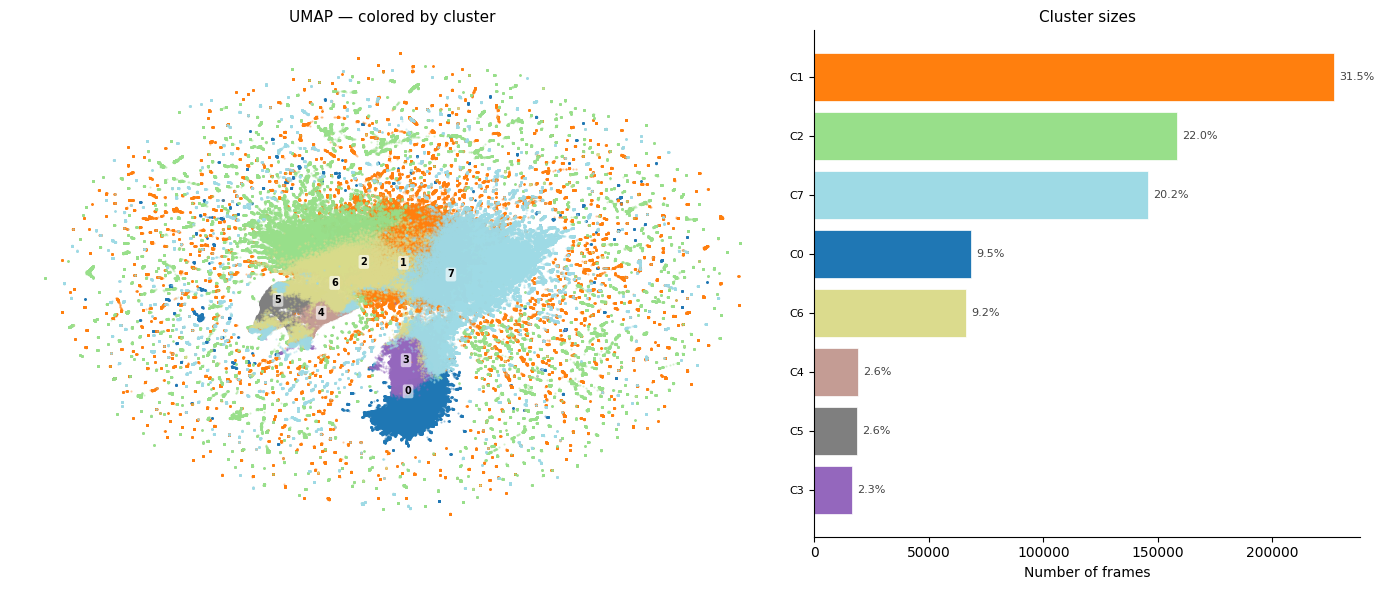

In [105]:
 plot_cluster_landscape(df)

/tmp/ipykernel_2577585/500170347.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20', n_clusters)


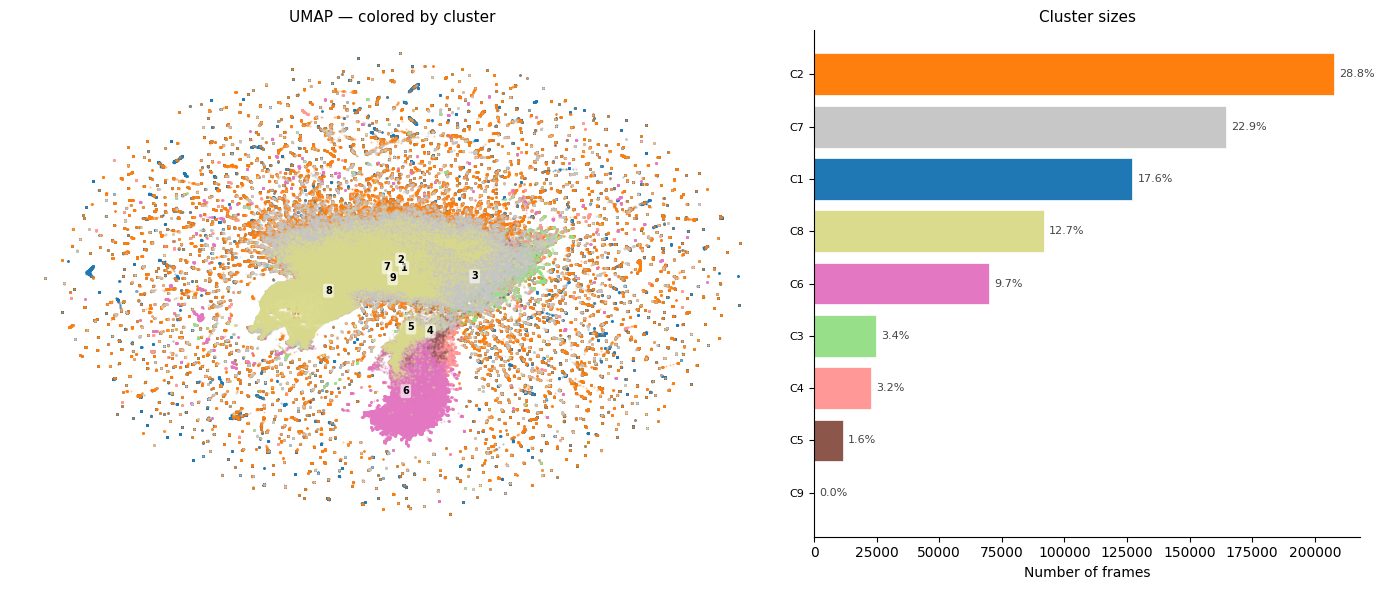

In [106]:
# with hlac label
plot_cluster_landscape(df,  cluster_label = 'hlac_label')

In [ ]:
# compare